In [85]:
!python --version

Python 3.12.13


In [86]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, ConfusionMatrixDisplay,
                            roc_curve, roc_auc_score)
np.random.seed(1)

## Category 3 Principal Components

### 3.1 Dataset
Three made-up stocks (A, B, C), where each one's daily return is mostly driven
by one shared, hidden "market mood," plus a bit of its own private noise.
This is exactly the kind of situation Principal Component Analysis (PCA) is
designed for: several things that move together, where there might be one
(or a few) underlying drivers behind all of them.

In [87]:
n = 250
market_mood = np.random.normal(0, 1.5, n) # the hidden shared factor

stock_A = 1.1 * market_mood + np.random.normal(0, 0.8, n)
stock_B = 0.9 * market_mood + np.random.normal(0, 0.8, n)
stock_C = 1.0 * market_mood + np.random.normal(0, 0.8, n)

returns = pd.DataFrame({"Stock_A": stock_A, "Stock_B": stock_B, "Stock_C": stock_C})
print("First 5 days of simulated returns (%):")
print(returns.head().round(2))

print()
print("How correlated are the three stocks with each other?")
print(returns.corr().round(2))

First 5 days of simulated returns (%):
   Stock_A  Stock_B  Stock_C
0     2.40     0.82     3.67
1    -1.19    -0.78    -0.92
2    -3.11    -1.35     0.24
3    -0.22    -1.68    -1.96
4     1.72     0.96     1.77

How correlated are the three stocks with each other?
         Stock_A  Stock_B  Stock_C
Stock_A     1.00     0.77     0.80
Stock_B     0.77     1.00     0.78
Stock_C     0.80     0.78     1.00


all three correlations are strongly positive (around 0.77-0.80).
These three "different" stocks are really telling us a lot of the same story
every day. That repetition is exactly what PCA can compress.

### 3.2 Put all 3 stocks on the same scale

PCA cares about how much each stock varies. If one stock's returns happened to
be measured in much bigger numbers than the others, it would unfairly dominate
just because of its scale - not because it's actually more important.
"Standardizing" puts all three stocks on equal footing before PCA looks at them.

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)
print("Done -- all three stocks now have an average of 0 and a spread of 1.")

Done -- all three stocks now have an average of 0 and a spread of 1.


### 3.3 Run PCA : sqeeue 3 stocks into few combined factor

PCA looks for the single direction along which the three stocks move around
the most, calls that Factor 1, then looks for the next-best leftover direction
(Factor 2), and so on. Each factor is just a specific weighted mix of the
 original stocks.

In [89]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca_scores = pca.fit_transform(returns_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)
print("How much of the total movement each new factor captures:")
for i, (e, c) in enumerate(zip(explained, cumulative), start=1):
    print(f"  Factor {i}: {e*100:.1f}% on its own   |   {c*100:.1f}% combined so far")

How much of the total movement each new factor captures:
  Factor 1: 85.6% on its own   |   85.6% combined so far
  Factor 2: 7.7% on its own   |   93.3% combined so far
  Factor 3: 6.7% on its own   |   100.0% combined so far


In plain English: a single combined factor already captures about 86% of
everything that's happening across all three stocks. We started with 3
numbers a day and could realistically get away with just 1, and only lose
about 14% of the picture.

### 3.4 How many factors do we need

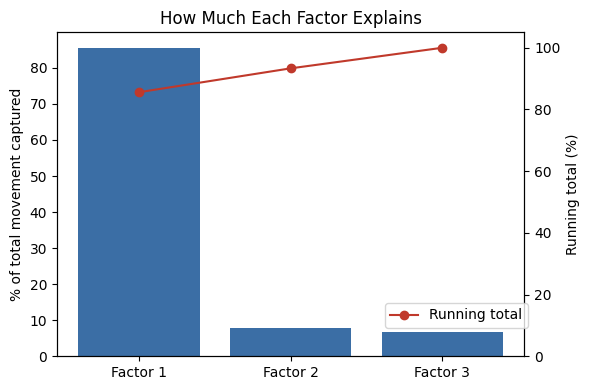

In [90]:
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.bar([f"Factor {i}" for i in range(1, 4)], explained * 100, color="#3b6ea5")
ax1.set_ylabel("% of total movement captured")
ax1.set_title("How Much Each Factor Explains")
ax2 = ax1.twinx()
ax2.plot([f"Factor {i}" for i in range(1, 4)], cumulative * 100, color="#c0392b",
         marker="o", label="Running total")
ax2.set_ylabel("Running total (%)")
ax2.set_ylim(0, 105)
fig.legend(loc="lower right", bbox_to_anchor=(0.9, 0.15))
plt.tight_layout()
plt.show()

How to read this chart: the blue bars show how much each individual factor
explains; the red line shows the running total as you add factors one by one.
This is called a "scree plot," and it's the standard way analysts decide how
many factors are worth keeping - you look for the point where adding another
factor barely moves the red line anymore.

### 3.5 What is Factor-1 exactly?

In [91]:
loadings = pd.DataFrame(pca.components_, columns=returns.columns,
                        index=["Factor 1", "Factor 2", "Factor 3"])
print("Factor 1's recipe (how much weight it puts on each stock):")
print(loadings.loc["Factor 1"].round(2))



Factor 1's recipe (how much weight it puts on each stock):
Stock_A    0.58
Stock_B    0.57
Stock_C    0.58
Name: Factor 1, dtype: float64


In plain English: Factor 1 weighs all three stocks almost equally. That's PCA,
with no help from us, rediscovering that there's basically one shared "market mood" driving all three stocks together - without us ever telling it that
market mood existed.



### 3.6 - See it directly on a chart


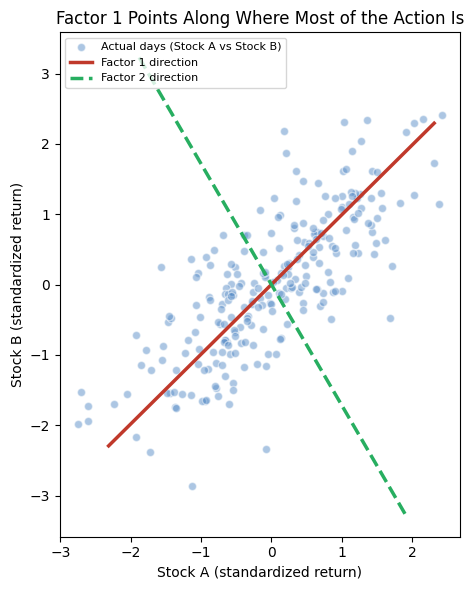

In [92]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(returns_scaled[:, 0], returns_scaled[:, 1], alpha=0.5, color="#5b8fc9",
           edgecolor="white", s=35, label="Actual days (Stock A vs Stock B)")

origin = np.array([0, 0])
direction_pc1 = pca.components_[0][:2]
scale = 4
ax.plot([origin[0] - direction_pc1[0]*scale, origin[0] + direction_pc1[0]*scale],
        [origin[1] - direction_pc1[1]*scale, origin[1] + direction_pc1[1]*scale],
        color="#c0392b", linewidth=2.5, label="Factor 1 direction")

direction_pc2 = pca.components_[1][:2]
ax.plot([origin[0] - direction_pc2[0]*scale, origin[0] + direction_pc2[0]*scale],
        [origin[1] - direction_pc2[1]*scale, origin[1] + direction_pc2[1]*scale],
        color="#27ae60", linewidth=2.5, linestyle="--", label="Factor 2 direction")

ax.set_xlabel("Stock A (standardized return)")
ax.set_ylabel("Stock B (standardized return)")
ax.set_title("Factor 1 Points Along Where Most of the Action Is")
ax.legend(loc="upper left", fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()



How to read this chart: every dot is one real day, comparing Stock A's move
against Stock B's move. The solid red line is Factor 1's direction - notice it
runs straight along the long axis of the cloud, exactly where the data spreads
out the most. The dashed green line, Factor 2, is perpendicular, picking up
whatever smaller, leftover spread Factor 1 missed.



### 3.7 - Does the 1-number version actually work?


Correlation between Factor 1 alone and the plain average of all 3 stocks: 1.000


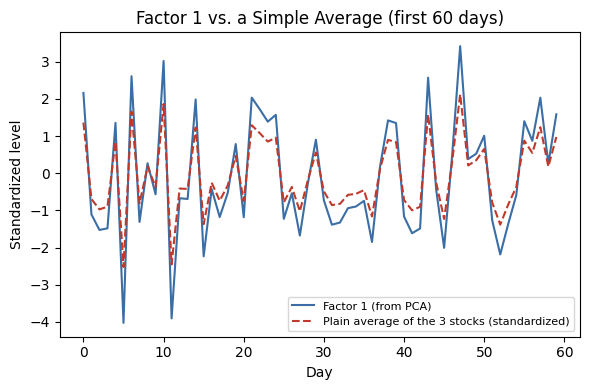

In [93]:
factor_1_score = pca_scores[:, 0]
simple_average = returns.mean(axis=1)
correlation = np.corrcoef(factor_1_score, simple_average)[0, 1]
print(f"Correlation between Factor 1 alone and the plain average of all 3 stocks: {correlation:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(factor_1_score[:60], label="Factor 1 (from PCA)", color="#3b6ea5")
ax.plot((simple_average[:60] - simple_average.mean()) / simple_average.std(),
        label="Plain average of the 3 stocks (standardized)", color="#c0392b", linestyle="--")
ax.set_xlabel("Day")
ax.set_ylabel("Standardized level")
ax.set_title("Factor 1 vs. a Simple Average (first 60 days)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



in this example, Factor 1 tracks a simple average of the
three stocks almost exactly. That's a nice sanity check - but it's also a hint
at where PCA earns its keep in real life: with only 3 nearly-identical stocks,
 an average would have worked almost as well. PCA becomes genuinely more useful
 than "just average everything" once you have many assets that aren't all
 pulling in the same direction - it finds the best possible combination
 automatically, instead of guessing that equal weights would do.

Main takeaway:
 - Three stocks that all move together can be boiled down to one "combined
   factor" that captures about 86% of everything happening across all of them.
 - PCA found this on its own - we never told it these stocks shared a common
   driver, it discovered that by looking for the direction along which the data naturally speards out the most.
 - The payoff of this kind of compression, at scale, is real: instead of tracking dozens or hundresds of correlated assets (or, classically in finance, dozens of interset rates along a yield curve), an analyst ca often track just a handful of factors and still catpure almost everything that matters.
 - The catch : the facros are mathematical combination not someting with an market mood. In messier real data, interpreting what a factor represent take more digging   

## Category 4 Classification Tree


In [94]:
np.random.seed(42)

### 4.1 Simulate a multi-asset price panel

In [95]:
n_assets = 5
n_days = 1000
asset_names = [f"Asset_{i+1}" for i in range(n_assets)]

mus = np.random.uniform(0.0002, 0.0006, n_assets)
sigmas = np.random.uniform(0.010, 0.022, n_assets)

dates = pd.bdate_range("2020-01-02", periods=n_days)

price_panels = {}
for i, name in enumerate(asset_names):
    daily_ret = np.random.normal(mus[i], sigmas[i] * 0.85, n_days)
    # inject a moderate autocorrelation/reversal term so the tree has
    # learnable (if noisy) structure -- mimics short-horizon momentum effects
    for t in range(2, n_days):
        daily_ret[t] += 0.16 * daily_ret[t-1] - 0.09 * daily_ret[t-2]
    prices = 100 * np.exp(np.cumsum(daily_ret))
    price_panels[name] = prices

price_df = pd.DataFrame(price_panels, index=dates)
print("Simulated price panel shape:", price_df.shape)
print(price_df.head())

Simulated price panel shape: (1000, 5)
               Asset_1     Asset_2     Asset_3     Asset_4     Asset_5
2020-01-02   99.562189  101.017471  101.199216  101.641397   99.261302
2020-01-03  100.143818  100.585405  102.908123  100.987543  100.280933
2020-01-06   99.843864  101.694059  100.290277  100.641907  100.574249
2020-01-07   99.310717  102.154409   98.465847  102.661659   98.357367
2020-01-08   99.529919  104.133224   97.149511  101.142758   96.501098


### 4.2 Feature engineering & target construction

In [96]:
def build_features(prices, name):
    df = pd.DataFrame(index=prices.index)
    ret = prices.pct_change()
    df["ret"] = ret
    df["lag1_ret"] = ret.shift(1)
    df["lag2_ret"] = ret.shift(2)
    df["lag3_ret"] = ret.shift(3)
    df["ma5"] = prices.rolling(5).mean() / prices - 1
    df["ma10"] = prices.rolling(10).mean() / prices - 1
    df["vol10"] = ret.rolling(10).std()
    df["momentum10"] = prices / prices.shift(10) - 1
    df["target"] = (ret.shift(-1) > 0).astype(int) # next-day direction
    df["asset"] = name
    df["date"] = df.index
    return df

panel_list = [build_features(price_df[a], a) for a in asset_names]
panel = pd.concat(panel_list).dropna()
panel = panel.sort_values("date").reset_index(drop=True)

feature_cols = ["lag1_ret", "lag2_ret", "lag3_ret", "ma5", "ma10", "vol10", "momentum10"]

print("Pooled panel shape (all assets stacked):", panel.shape)
print("\nTarget balance (1 = next-day up):")
print(panel["target"].value_counts(normalize=True).round(3))
print("\nFeature sample:")
print(panel[feature_cols + ["target"]].head())

Pooled panel shape (all assets stacked): (4950, 11)

Target balance (1 = next-day up):
target
1    0.522
0    0.478
Name: proportion, dtype: float64

Feature sample:
   lag1_ret  lag2_ret  lag3_ret       ma5      ma10     vol10  momentum10  \
0  0.002681 -0.009122 -0.006894  0.009563  0.034147  0.008452   -0.057827   
1 -0.044356 -0.018091  0.016238  0.042014  0.068654  0.018597   -0.094272   
2 -0.034531 -0.005171  0.000756  0.018242  0.036698  0.016934   -0.074004   
3  0.010652 -0.008779 -0.008837  0.003278  0.016565  0.011187   -0.036550   
4 -0.005181 -0.005813  0.004929  0.006610 -0.005818  0.009004    0.033304   

   target  
0       0  
1       1  
2       0  
3       0  
4       1  


### 4.3 Chronological train/test split

In [97]:
split_date = panel["date"].quantile(0.8)
train = panel[panel["date"] <= split_date]
test = panel[panel["date"] > split_date]

X_train, y_train = train[feature_cols], train["target"]
X_test, y_test = test[feature_cols], test["target"]

print(f"Split date (80th percentile of dates): {split_date.date()}")
print(f"Train obs: {len(train)} | Test obs: {len(test)}")

Split date (80th percentile of dates): 2023-01-27
Train obs: 3960 | Test obs: 990


### 4.4 Baseline classification tree (default hyper parameters)

In [98]:
baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)

print("Baseline (default hyperparameters) Decision Tree")
print("Train accuracy:", round(baseline.score(X_train, y_train), 4))
print("Test accuracy:", round(accuracy_score(y_test, base_pred), 4))
print(f"Tree depth grown: {baseline.get_depth()} | Leaves: {baseline.get_n_leaves()}")

Baseline (default hyperparameters) Decision Tree
Train accuracy: 1.0
Test accuracy: 0.502
Tree depth grown: 33 | Leaves: 966


### 4.5 Hyperparameter tuning via GridSearchCV

In [99]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, None],
    "min_samples_leaf": [10, 20, 40, 80],
    "ccp_alpha": [0.0, 0.00005, 0.0001, 0.0002],
}

tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Best params found via GridSearchCV (TimeSeriesSplit, 5 folds):")
print(grid.best_params_)
print("Best CV ROC-AUC (train folds):", round(grid.best_score_, 4))

best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, best_pred)
test_auc = roc_auc_score(y_test, best_proba)

print("\nTuned model performance on held-out test set:")
print("Test accuracy:", round(test_acc, 4))
print("Test ROC-AUC:", round(test_auc, 4))
print(f"Tree depth used: {best_model.get_depth()} | Leaves: {best_model.get_n_leaves()}")
print("\nClassification report (test set):")
print(classification_report(y_test, best_pred, target_names=["Down (0)", "Up (1)"]))

Best params found via GridSearchCV (TimeSeriesSplit, 5 folds):
{'ccp_alpha': 0.0, 'max_depth': 4, 'min_samples_leaf': 10}
Best CV ROC-AUC (train folds): 0.537

Tuned model performance on held-out test set:
Test accuracy: 0.5121
Test ROC-AUC: 0.5064
Tree depth used: 4 | Leaves: 15

Classification report (test set):
              precision    recall  f1-score   support

    Down (0)       0.48      0.27      0.34       474
      Up (1)       0.52      0.74      0.61       516

    accuracy                           0.51       990
   macro avg       0.50      0.50      0.48       990
weighted avg       0.50      0.51      0.48       990



### 4.6 Confusion matrix (test set)

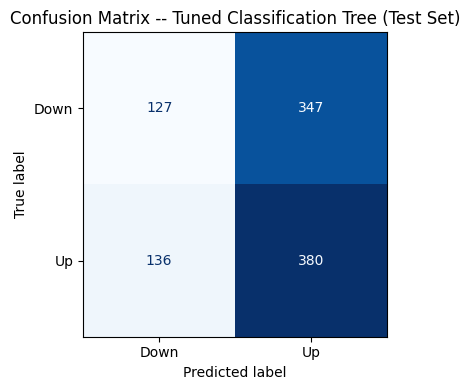

[[127 347]
 [136 380]]


In [100]:
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix -- Tuned Classification Tree (Test Set)")
plt.tight_layout()
plt.show()
print(cm)

### 4.7 Feature importance

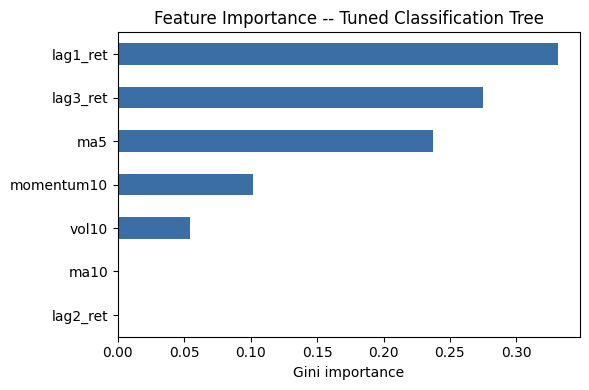

lag1_ret      0.331346
lag3_ret      0.274726
ma5           0.237442
momentum10    0.102103
vol10         0.054383
ma10          0.000000
lag2_ret      0.000000
dtype: float64


In [101]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_title("Feature Importance -- Tuned Classification Tree")
ax.set_xlabel("Gini importance")
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

### 4.8 Illustration : visualizing fitted tree

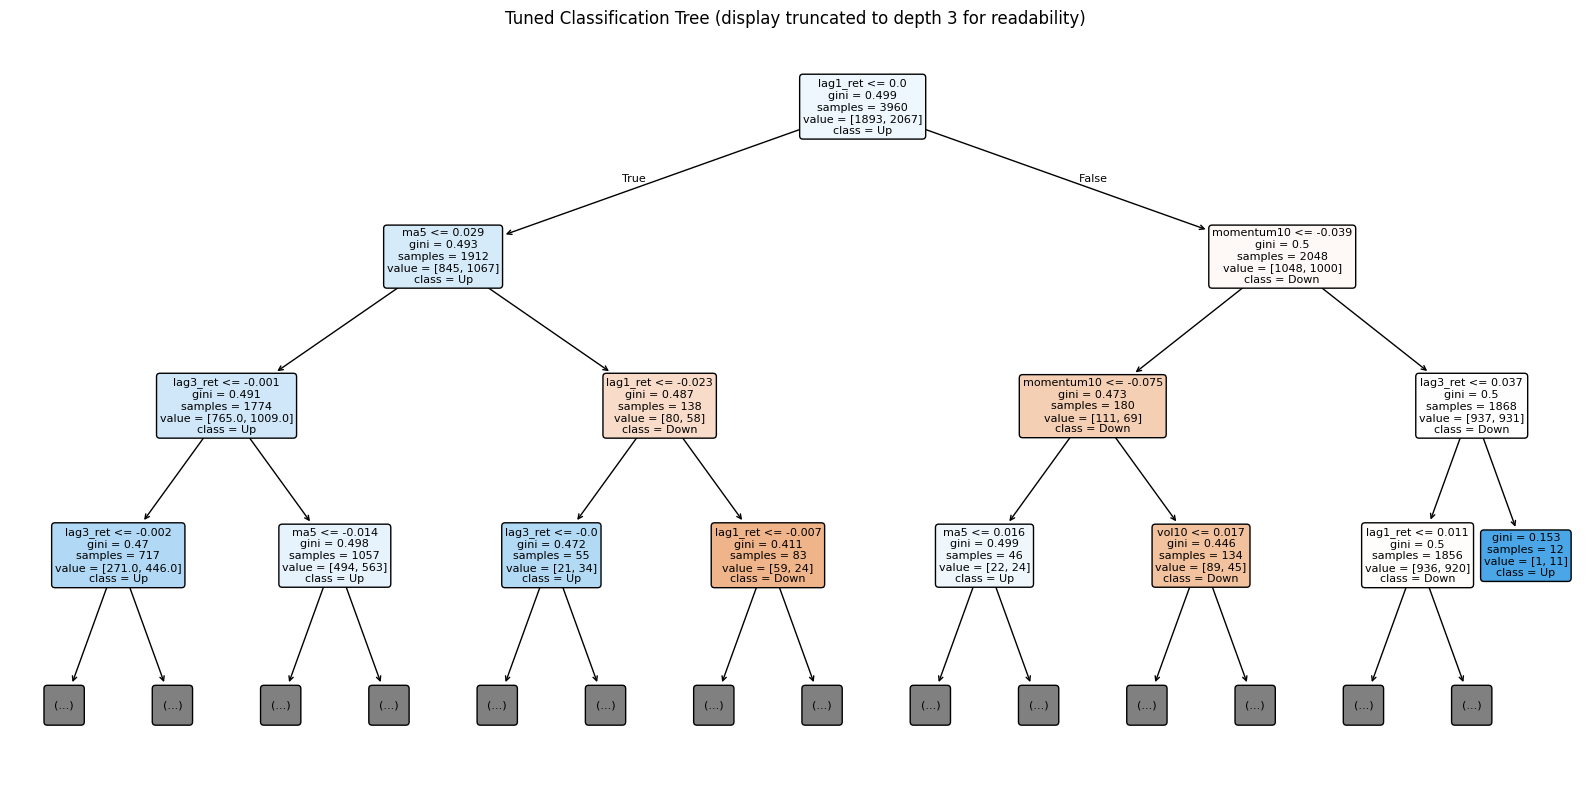

Full fitted tree depth: 4 | Leaves: 15


In [102]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(best_model, feature_names=feature_cols, class_names=["Down", "Up"],
          filled=True, rounded=True, fontsize=8, ax=ax, max_depth=3)
ax.set_title("Tuned Classification Tree (display truncated to depth 3 for readability)")
plt.tight_layout()
plt.show()
print("Full fitted tree depth:", best_model.get_depth(), "| Leaves:", best_model.get_n_leaves())

### 4.9 ROC curve (test set)

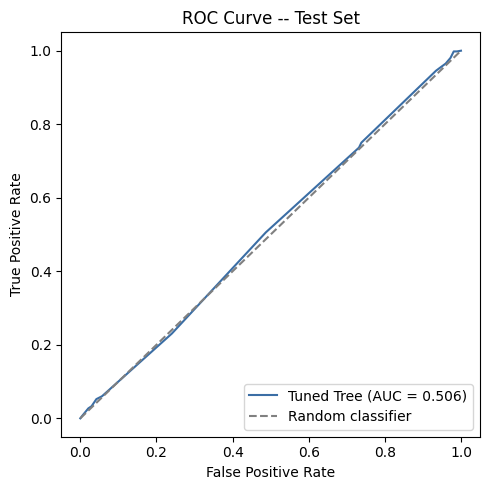

Test ROC-AUC: 0.5064


In [103]:
fpr, tpr, _ = roc_curve(y_test, best_proba)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#3b6ea5", label=f"Tuned Tree (AUC = {test_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve -- Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
print("Test ROC-AUC:", round(test_auc, 4))

### 4.10 Overfitting diagnostic : accuracy vs tree depth

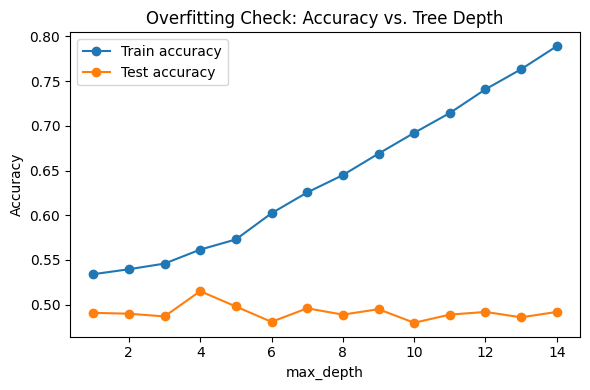

In [81]:
depths = list(range(1, 15))
train_accs, test_accs = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(m.score(X_train, y_train))
    test_accs.append(m.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(depths, train_accs, marker="o", label="Train accuracy")
ax.plot(depths, test_accs, marker="o", label="Test accuracy")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Overfitting Check: Accuracy vs. Tree Depth")
ax.legend()
plt.tight_layout()
plt.show()

## Category 6 Support Vector Machine

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_circles

In [105]:
np.random.seed(0)

### 6.1 Dataset

In [84]:
n = 160
leverage = np.random.uniform(0.2, 3.5, n)
margin = np.random.uniform(-5, 20, n)

# A simple made-up rule, plus randomness: high leverage + low margin -> high risk
score = -1.1 * leverage + 0.35 * margin + np.random.normal(0, 1.3, n)
risk = (score < 0).astype(int) # 1 = High risk, 0 = Low risk

data = pd.DataFrame({"leverage": leverage, "profit_margin": margin, "high_risk": risk})
print("First 5 companies in our simple dataset:")
print(data.head().round(2))
print()
print("How many High risk vs Low risk companies:")
print(data["high_risk"].value_counts().rename({1: "High risk", 0: "Low risk"}))

First 5 companies in our simple dataset:
   leverage  profit_margin  high_risk
0      2.01          12.44          0
1      2.56           6.34          1
2      2.19          13.05          0
3      2.00          16.66          0
4      1.60          19.39          0

How many High risk vs Low risk companies:
high_risk
Low risk     87
High risk    73
Name: count, dtype: int64


### 6.2 Set some companies aside to test on later

In [106]:
X = data[["leverage", "profit_margin"]].values
y = data["high_risk"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(f"Training companies: {len(X_train)}  |  Test companies: {len(X_test)}")

Training companies: 112  |  Test companies: 48


### 6.3 Fit a Support Vector Machine

An SVM's whole job is to draw the one dividing line that leaves the widest
 possible gap between the two groups - not just any line that happens to
 separate them, but the one with the most breathing room on both sides.
 That gap is called the margin.

In [107]:
svm = SVC(kernel="linear", C=1.0)
svm.fit(X_train, y_train)

train_acc = svm.score(X_train, y_train)
test_acc = svm.score(X_test, y_test)
n_support = len(svm.support_)
print(f"Accuracy on training companies:  {train_acc:.2f}")
print(f"Accuracy on test companies:      {test_acc:.2f}")
print(f"Number of 'support vectors' (the borderline cases the model relies on): {n_support}")

Accuracy on training companies:  0.88
Accuracy on test companies:      0.90
Number of 'support vectors' (the borderline cases the model relies on): 31


the model got 90% of the test companies right, even though  it had never seen them before. The "support vectors" are the handful of
companies sitting closest to the boundary between the two groups - they're
 the only ones that actually matter for deciding exactly where the line goes.
 Every company far away from the boundary could be deleted and the line
 wouldn't move at all.

### 6.4 See exactly where it got things right or wrong


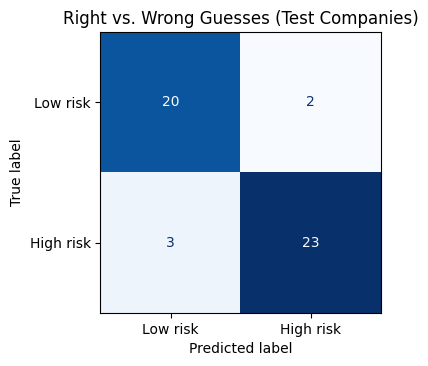

[[20  2]
 [ 3 23]]


In [108]:
pred = svm.predict(X_test)
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Low risk", "High risk"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Right vs. Wrong Guesses (Test Companies)")
plt.tight_layout()
plt.show()
print(cm)

### 6.5 See the dividing line, the margin, and the support vectors

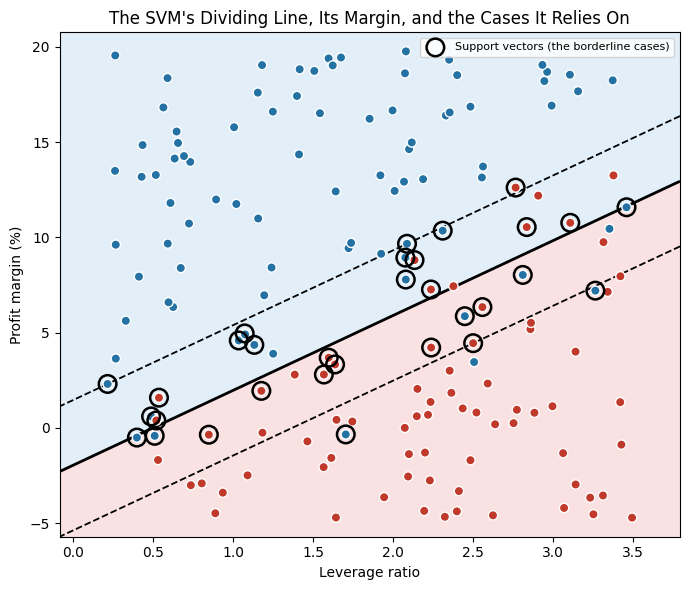

In [109]:
fig, ax = plt.subplots(figsize=(7, 6))
cmap_bg = ListedColormap(["#c6e0f5", "#f7c6c6"])
cmap_pts = ListedColormap(["#2471a3", "#c0392b"])

x1_range = np.linspace(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, 300)
x2_range = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid_pred = svm.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
ax.contourf(xx1, xx2, grid_pred, cmap=cmap_bg, alpha=0.5)

Z = svm.decision_function(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
ax.contour(xx1, xx2, Z, colors="black", levels=[-1, 0, 1], linestyles=["--", "-", "--"],
           linewidths=[1.3, 2, 1.3])

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pts, edgecolor="white", s=45, zorder=3)
ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
           facecolors="none", edgecolors="black", s=160, linewidths=1.8, zorder=4,
           label="Support vectors (the borderline cases)")

ax.set_xlabel("Leverage ratio")
ax.set_ylabel("Profit margin (%)")
ax.set_title("The SVM's Dividing Line, Its Margin, and the Cases It Relies On")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

 How to read this chart: the solid black line is the SVM's dividing line.
 The two dashed lines on either side mark the margin - the widest buffer zone
 the model could fit between the two groups. The circled points are the support
 vectors: the specific companies sitting right on the edge of that buffer zone,
 which are the only ones the line's exact position actually depends on.

6.5 Part 2 : When a straight line isn't enough (the "kernel trick")When stra

 Sometimes two groups can't be separated by any straight line, no matter how
 you draw it. Imagine a "Stress" market regime that sits entirely inside a ring
 of "Normal" days - a straight line can never wrap around a ring.

 SVMs handle this with something called a kernel - a mathematical trick that
 lets the model draw a curved boundary instead of a straight one, without
 fundamentally changing how the method works.

In [110]:
X_ring, y_ring = make_circles(n_samples=200, noise=0.12, factor=0.4, random_state=0)
labels_ring = pd.Series(y_ring).map({0: "Normal", 1: "Stress"})
print("Ring-shaped example, class counts:")
print(labels_ring.value_counts())

svm_linear = SVC(kernel="linear").fit(X_ring, y_ring)
svm_rbf = SVC(kernel="rbf", gamma=2).fit(X_ring, y_ring)

print()
print(f"Straight-line (linear) SVM accuracy on this ring-shaped data: {svm_linear.score(X_ring, y_ring):.2f}")
print(f"Curved (RBF) SVM accuracy on the same data:                  {svm_rbf.score(X_ring, y_ring):.2f}")

Ring-shaped example, class counts:
Normal    100
Stress    100
Name: count, dtype: int64

Straight-line (linear) SVM accuracy on this ring-shaped data: 0.62
Curved (RBF) SVM accuracy on the same data:                  0.99


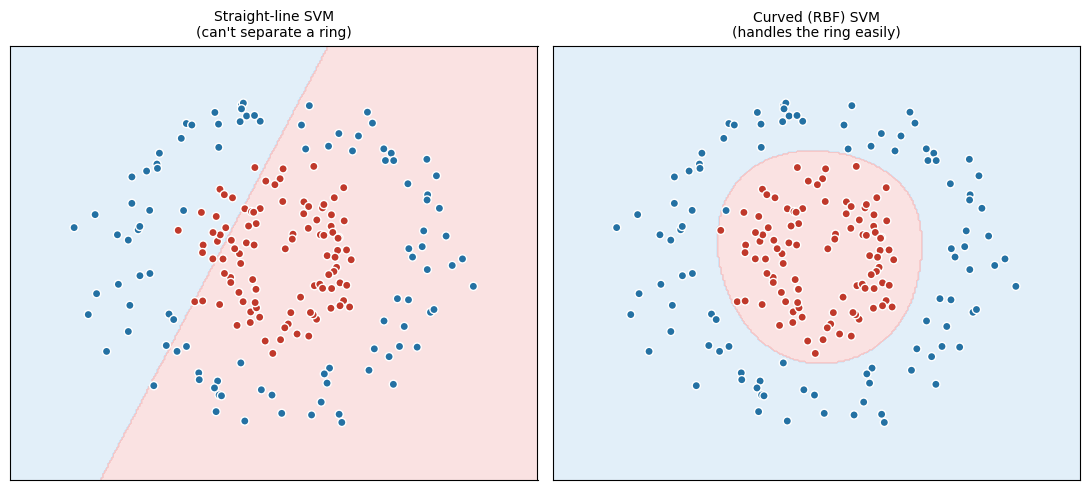

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
xr = np.linspace(X_ring[:, 0].min() - 0.4, X_ring[:, 0].max() + 0.4, 300)
yr = np.linspace(X_ring[:, 1].min() - 0.4, X_ring[:, 1].max() + 0.4, 300)
xxr, yyr = np.meshgrid(xr, yr)

for ax, model, title in zip(axes, [svm_linear, svm_rbf],
                            ["Straight-line SVM\n(can't separate a ring)",
                             "Curved (RBF) SVM\n(handles the ring easily)"]):
    zz = model.predict(np.c_[xxr.ravel(), yyr.ravel()]).reshape(xxr.shape)
    ax.contourf(xxr, yyr, zz, cmap=ListedColormap(["#c6e0f5", "#f7c6c6"]), alpha=0.5)
    ax.scatter(X_ring[:, 0], X_ring[:, 1], c=y_ring,
               cmap=ListedColormap(["#2471a3", "#c0392b"]), edgecolor="white", s=35)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

the straight-line version gets barely more than half right
 (62%) - it physically cannot wrap around a ring. Swap in a curved (RBF)
 kernel, change nothing else about the method, and accuracy jumps to 99%.
 This is the entire idea behind the kernel trick - the same underlying
 approach, just allowed to draw a more flexible boundary shape.

Main takeaway
 - An SVM doesn't just find any line that separates two groups - it finds the
   one with the widest possible safety margin, which tends to make it more
   reliable on new, unseen data.
 - Only the borderline cases (the support vectors) actually determine where
   that line goes - everything else could be removed without changing the
   result.
 - When a straight line genuinely can't do the job, switching the SVM's
   kernel lets it draw a curved boundary instead - without needing an entirely
   different method.
 - As with the classification tree example, this is not a "trade purely off
   this model" result - it's a clean illustration of the mechanics. Real
   deployment would need real data, more features, and careful validation.